In [13]:
import torch
import torch.nn as nn


class SingleFrameCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            # (B,3,224,224) -> (B,32,112,112)
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # -> (B,64,56,56)
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # -> (B,128,28,28)
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # -> (B,256,14,14)
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # -> (B,256,7,7)
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # (B,256,1,1)
            nn.Flatten(),                  # (B,256)
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(128, num_classes),   # logits
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SingleFrameCNN(num_classes=3).to(device)

x = torch.zeros((1, 3, 224, 224), device=device)
logits = model(x)

print(logits.shape)  # torch.Size([1, 3])

torch.Size([1, 3])


In [15]:
#print number of parameters
total_params = sum(p.numel() for p in model.parameters())   
print(f"Total parameters: {total_params}")

Total parameters: 1013251


In [1]:
import csv
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class FrameControlSequenceDataset(Dataset):
    """
    Reads a CSV with columns: filename,left,right
    Loads frames sequentially from frames_dir.

    Target mapping (your rule):
      (0,0) -> None
      (1,1) -> None
      (1,0) -> Left
      (0,1) -> Right

    Returns:
      x: (3,H,W) float32 in [0,1]
      y: int64 class index {0:Left, 1:None, 2:Right}
      fname: filename
    """

    def __init__(self, csv_path: str, frames_dir: str, image_size=(224, 224)):
        self.csv_path = Path(csv_path)
        self.frames_dir = Path(frames_dir)

        if not self.csv_path.exists():
            raise FileNotFoundError(f"CSV not found: {self.csv_path}")
        if not self.frames_dir.exists():
            raise FileNotFoundError(f"Frames dir not found: {self.frames_dir}")

        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),  # /255 -> [0,1]
        ])

        # Read CSV rows
        rows = []
        with open(self.csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            for r in reader:
                fname = r["filename"]
                left = int(r["left"])
                right = int(r["right"])
                rows.append((fname, left, right))

        # Sort explicitly by filename to preserve frame order
        rows.sort(key=lambda t: t[0])
        self.rows = rows

        # Class mapping
        self.class_names = ["Left", "None", "Right"]

    def __len__(self):
        return len(self.rows)

    def _to_class_index(self, left: int, right: int) -> int:
        # 0: Left, 1: None, 2: Right
        if (left == 0 and right == 0) or (left == 1 and right == 1):
            return 1  # None
        if left == 1 and right == 0:
            return 0  # Left
        if left == 0 and right == 1:
            return 2  # Right
        # Fallback (shouldn't happen)
        return 1

    def __getitem__(self, idx):
        fname, left, right = self.rows[idx]
        img_path = self.frames_dir / fname
        if not img_path.exists():
            raise FileNotFoundError(f"Missing frame: {img_path}")

        with Image.open(img_path) as im:
            im = im.convert("RGB")
            x = self.transform(im)

        y = torch.tensor(self._to_class_index(left, right), dtype=torch.long)
        return x, y, fname
    

import csv
import random
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset
from torchvision import transforms


class FrameControlSequenceDataset(Dataset):
    """
    Sequence dataset with controlled class imbalance.

    - Keeps ALL Left and Right frames
    - Samples up to `max_none_per_epoch` None frames per epoch
    - Resampling happens by calling `set_epoch(epoch)`
    - Order is preserved (important for temporal models)
    """

    def __init__(
        self,
        csv_path: str,
        frames_dir: str,
        image_size=(224, 224),
        max_none_per_epoch: int = 30_000,
        seed: int = 42,
    ):
        self.csv_path = Path(csv_path)
        self.frames_dir = Path(frames_dir)
        self.max_none_per_epoch = max_none_per_epoch
        self.seed = seed

        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),  # /255
        ])

        # Load CSV
        rows = []
        with open(self.csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            for r in reader:
                fname = r["filename"]
                left = int(r["left"])
                right = int(r["right"])
                rows.append((fname, left, right))

        # Sort by filename to preserve temporal order
        rows.sort(key=lambda t: t[0])
        self.rows = rows

        # Split indices by class
        self.left_idx = []
        self.right_idx = []
        self.none_idx = []

        for i, (_fname, left, right) in enumerate(self.rows):
            if left == 1 and right == 0:
                self.left_idx.append(i)
            elif left == 0 and right == 1:
                self.right_idx.append(i)
            else:
                self.none_idx.append(i)

        self.class_names = ["Left", "None", "Right"]

        # Build first epoch index list
        self.set_epoch(0)

    def set_epoch(self, epoch: int):
        """
        Call this at the start of every epoch to resample None frames.
        """
        rng = random.Random(self.seed + epoch)

        # Sample None indices
        if len(self.none_idx) > self.max_none_per_epoch:
            sampled_none = rng.sample(self.none_idx, self.max_none_per_epoch)
        else:
            sampled_none = list(self.none_idx)

        # Combine all indices and keep temporal order
        active = set(self.left_idx + self.right_idx + sampled_none)
        self.active_indices = [i for i in range(len(self.rows)) if i in active]

    def __len__(self):
        return len(self.active_indices)

    def _to_class_index(self, left: int, right: int) -> int:
        # 0: Left, 1: None, 2: Right
        if (left == 0 and right == 0) or (left == 1 and right == 1):
            return 1
        if left == 1 and right == 0:
            return 0
        if left == 0 and right == 1:
            return 2
        return 1

    def __getitem__(self, idx):
        real_idx = self.active_indices[idx]
        fname, left, right = self.rows[real_idx]

        img_path = self.frames_dir / fname
        if not img_path.exists():
            raise FileNotFoundError(f"Missing frame: {img_path}")

        with Image.open(img_path) as im:
            im = im.convert("RGB")
            x = self.transform(im)

        y = torch.tensor(self._to_class_index(left, right), dtype=torch.long)
        return x, y, fname



In [19]:
csv_path = r"D:\Data\Game Dataset\az_recorder_20260103_125453s_GamePlay_224x224_synced.csv"
frames_dir = r"D:\Data\Game Dataset\az_recorder_20260103_125453s_GamePlay_224x224"

ds = FrameControlSequenceDataset(csv_path=csv_path, frames_dir=frames_dir, image_size=(224, 224))
dl = DataLoader(ds, batch_size=1, shuffle=False)


In [16]:
import random
import matplotlib.pyplot as plt


def visualize_random_samples(dataset, class_names, n=4):
    """
    Randomly visualize `n` samples from a FrameControlSequenceDataset.

    Args:
        dataset: FrameControlSequenceDataset
        class_names: list like ["Left", "None", "Right"]
        n: number of samples to show (default=4)
    """

    assert len(dataset) >= n, "Dataset smaller than number of samples requested"

    indices = random.sample(range(len(dataset)), n)

    plt.figure(figsize=(12, 6))

    for i, idx in enumerate(indices):
        x, y, fname = dataset[idx]

        # x is (3,H,W) tensor in [0,1]
        img = x.permute(1, 2, 0).numpy()

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{fname}\nLabel: {class_names[y.item()]}")

    plt.tight_layout()
    plt.show()


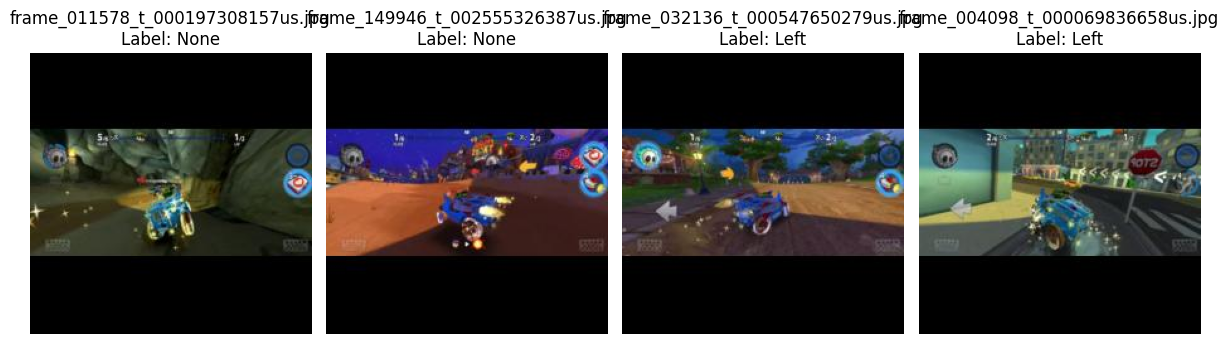

In [28]:
visualize_random_samples(
    dataset=ds,
    class_names=["Left", "None", "Right"],
    n=4,
)


In [29]:
import time
import torch
import torch.nn as nn


def train_single_frame_cnn(
    model,
    dataloader,
    class_names,
    epochs=5,
    lr=1e-4,
    weight_decay=1e-4,
    device=None,
    print_every=50,
    save_path="single_frame_cnn.pt",
):
    """
    Training loop for single-frame CNN classifier.

    Assumes dataloader yields:
      x: (B,3,224,224)
      y: (B,) class indices
      fname: filename (unused except for debugging)
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        running_correct = 0
        seen = 0

        t0 = time.time()

        for step, batch in enumerate(dataloader, start=1):
            x, y, _fname = batch

            x = x.to(device)
            y = y.to(device).view(-1)

            optimizer.zero_grad(set_to_none=True)

            logits = model(x)
            loss = criterion(logits, y)

            loss.backward()
            optimizer.step()

            preds = logits.argmax(dim=1)

            B = x.shape[0]
            running_loss += loss.item() * B
            running_correct += (preds == y).sum().item()
            seen += B

            if (step % print_every == 0) or (step == 1) or (step == len(dataloader)):
                avg_loss = running_loss / max(seen, 1)
                avg_acc = running_correct / max(seen, 1)

                tgt_name = class_names[y[0].item()]
                pred_name = class_names[preds[0].item()]

                print(
                    f"Epoch {epoch:02d}/{epochs} | "
                    f"Step {step:05d}/{len(dataloader):05d} | "
                    f"loss={avg_loss:.4f} acc={avg_acc:.4f} | "
                    f"target={tgt_name} pred={pred_name}"
                )

        epoch_time = time.time() - t0
        epoch_loss = running_loss / max(seen, 1)
        epoch_acc = running_correct / max(seen, 1)

        print(
            f"Epoch {epoch:02d} done | "
            f"loss={epoch_loss:.4f} acc={epoch_acc:.4f} | "
            f"time={epoch_time:.1f}s"
        )

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
        },
        save_path,
    )
    print(f"Saved model to: {save_path}")

    return model


In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SingleFrameCNN(num_classes=3).to(device)

trained_model = train_single_frame_cnn(
    model=model,
    dataloader=dl,   # DataLoader(FrameControlSequenceDataset, batch_size=32 or 1)
    class_names=["Left", "None", "Right"],
    epochs=10,
    lr=1e-4,
    print_every=50,
    device=device,
)


Epoch 01/10 | Step 00001/61215 | loss=0.8713 acc=1.0000 | target=None pred=None
Epoch 01/10 | Step 00050/61215 | loss=0.1683 acc=1.0000 | target=None pred=None
Epoch 01/10 | Step 00100/61215 | loss=0.2299 acc=0.9700 | target=Left pred=None
Epoch 01/10 | Step 00150/61215 | loss=0.5992 acc=0.7667 | target=Left pred=None
Epoch 01/10 | Step 00200/61215 | loss=0.7123 acc=0.6850 | target=None pred=None
Epoch 01/10 | Step 00250/61215 | loss=0.7831 acc=0.6480 | target=Right pred=Right
Epoch 01/10 | Step 00300/61215 | loss=0.8443 acc=0.6133 | target=None pred=Right
Epoch 01/10 | Step 00350/61215 | loss=0.8283 acc=0.6514 | target=Right pred=Right
Epoch 01/10 | Step 00400/61215 | loss=0.8762 acc=0.6150 | target=Left pred=Right
Epoch 01/10 | Step 00450/61215 | loss=0.9174 acc=0.5756 | target=None pred=None
Epoch 01/10 | Step 00500/61215 | loss=0.9181 acc=0.5820 | target=None pred=None
Epoch 01/10 | Step 00550/61215 | loss=0.9236 acc=0.5600 | target=None pred=None
Epoch 01/10 | Step 00600/61215 | l

KeyboardInterrupt: 